<a href="https://colab.research.google.com/github/muhyassin09/yasinnn/blob/main/menuju-indonesia-emas-2045/notebooks/03_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Name: Indonesian Municipal Fiscal Analytics Framework
## Module: 03_Modelling

**Project Pipeline Status:**
- [x] **00_Data_Acquisition.ipynb** -> Documents the source publication and how the raw table data was extracted from BPS PDF reports.
- [x] **01_Data_Preprocessing.ipynb** -> Loads the raw BPS fiscal CSV and runs data-quality checks (shape, dtypes, missing values, duplicates).
- [x] **02_Data_Analysis.ipynb** -> Explores distribution shape/skewness of the 8 fiscal ratios and applies a log1p transform where it helps.
- [ ] **03_Modelling.ipynb** *(current)* -> Standardizes features, selects k, fits K-Means (k=4), and profiles/visualizes the resulting clusters.
- [ ] **04_Finalizing.ipynb** -> Checks the geographic pattern of clusters, saves the final labeled dataset, and writes the project summary.

---
### 🎯 Module Objective
Group the 508 regions into interpretable fiscal profiles using K-Means: standardize the log-transformed indicators, select k, fit the model, profile each cluster, and visualize the result via PCA.

### 📥 Data Ingestion
* **Source File:** `data/processed/processed_fiscal_indicators_indonesia_2023.csv`
* **Current Shape:** 508 rows × 18 columns (original + log-transformed indicators)

---


### 🛠️ Environment Setup

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [1]:
!git clone https://github.com/muhyassin09/yasinnn/

Cloning into 'yasinnn'...
remote: Enumerating objects: 651, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 651 (delta 45), reused 9 (delta 9), pack-reused 583 (from 1)
Receiving objects: 100% (651/651), 19.43 MiB | 19.54 MiB/s, done.
Resolving deltas: 100% (281/281), done.


In [4]:
df = pd.read_csv('/content/yasinnn/menuju-indonesia-emas-2045/data/processed/processed_fiscal_indicators_indonesia_2023.csv')

In [5]:
ratio_cols = [
    'derajat_desentralisasi_2023',
    'rasio_kemandirian_2023',
    'tingkat_penyerapan_pendapatan',
    'tingkat_penyerapan_belanja',
    'rasio_pajak',
    'rasio_efektivitas_pad',
    'rasio_efektivitas_pajak',
    'rasio_belanja_thd_pendapatan',
]
log_cols = [f'log_{col}' for col in ratio_cols]
print('Loaded shape:', df.shape)


Loaded shape: (508, 18)


---
## 7. Clustering: fiscal profile segmentation

Now that the data is clean and log-transformed, we group the 508 regions into fiscal profiles using K-Means. The goal isn't to find perfectly separated clusters (real socioeconomic data rarely has hard boundaries) — it's to surface a small number of interpretable groups that tell a coherent policy story.

We continue directly with `df` from the preprocessing steps above — no need to reload anything.

### 7.1 Standardize the features

K-Means is distance-based, so features need comparable scales. We standardize the log-transformed indicators (z-score: mean 0, standard deviation 1).

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(df[log_cols])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (508, 8)


### 7.2 Choosing k

We fit K-Means across a range of `k` and look at two diagnostics:
- **Inertia** — within-cluster sum of squares; look for where the improvement slows down (the "elbow").
- **Silhouette score** — how well-separated clusters are (higher is better, max 1.0).

Neither metric alone gives a "correct" `k`, especially for continuous, real-world data like this where regions sit on a spectrum rather than in discrete boxes.

In [7]:
results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    results.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})

results_df = pd.DataFrame(results)
print(results_df.round(3))

   k   inertia  silhouette
0  2  3128.396       0.225
1  3  2632.200       0.222
2  4  2336.018       0.212
3  5  2111.007       0.187
4  6  1942.520       0.170
5  7  1793.981       0.182
6  8  1702.295       0.189


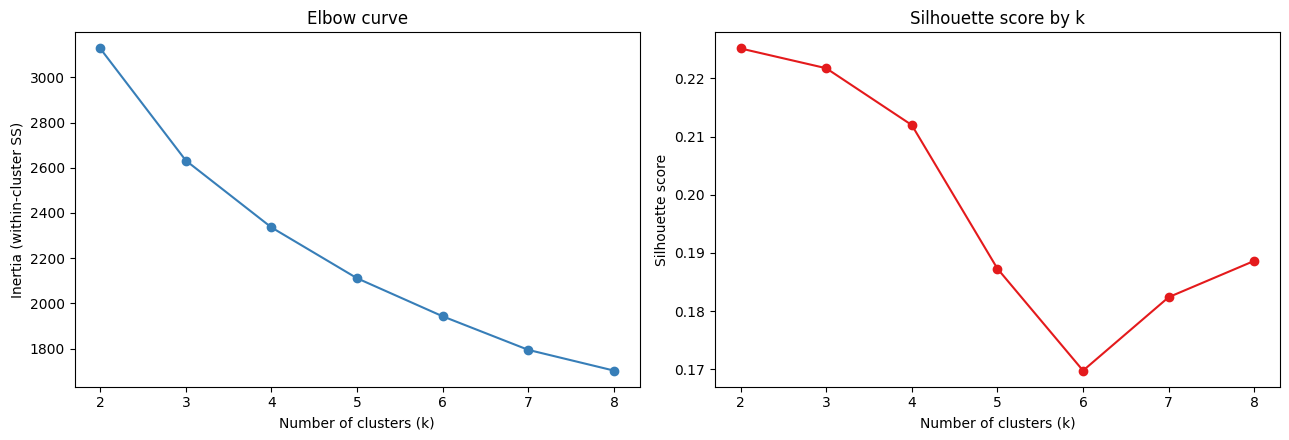

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(results_df['k'], results_df['inertia'], marker='o', color='#377eb8')
axes[0].set_title('Elbow curve')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SS)')

axes[1].plot(results_df['k'], results_df['silhouette'], marker='o', color='#e41a1c')
axes[1].set_title('Silhouette score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.savefig('fig3_elbow_silhouette')
plt.show()

**Reading these plots honestly:** the elbow curve has no sharp bend, and silhouette scores are modest throughout (peaking around 0.22–0.23 at k=2–3). This tells us fiscal capacity across these regions is more of a continuum than a set of cleanly separated groups — realistic for socioeconomic data, not a modeling failure.

We choose **k = 4**: its silhouette score (~0.21) sits close to the best score, and four groups gives a policy-readable segmentation rather than an uninformatively coarse k=2. This is a chosen framing for interpretability, not a value forced by the statistics.

In [9]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

df['cluster'].value_counts().sort_index()

,count
cluster,
0,74
1,46
2,156
3,232


### 7.3 Profiling the clusters

We look at the average of each *original* (non-log) indicator per cluster to understand what each group actually represents in real fiscal terms.

In [10]:
cluster_profile = df.groupby('cluster')[ratio_cols].mean().round(2)
cluster_profile.insert(0, 'n_regions', df['cluster'].value_counts().sort_index())
cluster_profile

,n_regions,derajat_desentralisasi_2023,rasio_kemandirian_2023,tingkat_penyerapan_pendapatan,tingkat_penyerapan_belanja,rasio_pajak,rasio_efektivitas_pad,rasio_efektivitas_pajak,rasio_belanja_thd_pendapatan
cluster,,,,,,,,,
0,74,4.62,5.02,97.91,94.83,1.35,67.05,63.45,99.51
1,46,8.12,9.33,124.52,113.85,2.94,187.86,140.77,95.44
2,156,24.95,40.23,103.05,99.04,14.07,103.57,107.17,101.70
3,232,8.29,9.32,102.94,100.49,2.42,109.91,106.38,102.07


Based on these averages, we assign interpretable labels. **This is an analytical judgment call, not an automated output** — always name clusters after looking at what actually distinguishes them, not just their number.

> Note: K-Means cluster numbering is arbitrary and can shift between environments. Check the profile table above matches this description before trusting the mapping below.

In [11]:
cluster_labels = {
    0: 'Dependent / Underperforming',
    1: 'Resource-Windfall Overperformers',
    2: 'Fiscally Autonomous',
    3: 'Stable / Average',
}

df['cluster_label'] = df['cluster'].map(cluster_labels)
df[['kabupaten_kota', 'provinsi', 'cluster', 'cluster_label']].head()

,kabupaten_kota,provinsi,cluster,cluster_label
0,Kab. Aceh Barat,Aceh,3,Stable / Average
1,Kab. Aceh Barat Daya,Aceh,3,Stable / Average
2,Kab. Aceh Besar,Aceh,3,Stable / Average
3,Kab. Aceh Jaya,Aceh,3,Stable / Average
4,Kab. Aceh Selatan,Aceh,3,Stable / Average


### 7.4 Visualizing the clusters

K-Means operated on 8 dimensions, which we can't plot directly. We use PCA to project down to 2 dimensions for visualization only — clustering itself was already done in the full 8-dimensional space above.

In [12]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
df['pc1'] = coords[:, 0]
df['pc2'] = coords[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")

Explained variance: PC1=36.8%, PC2=29.3%


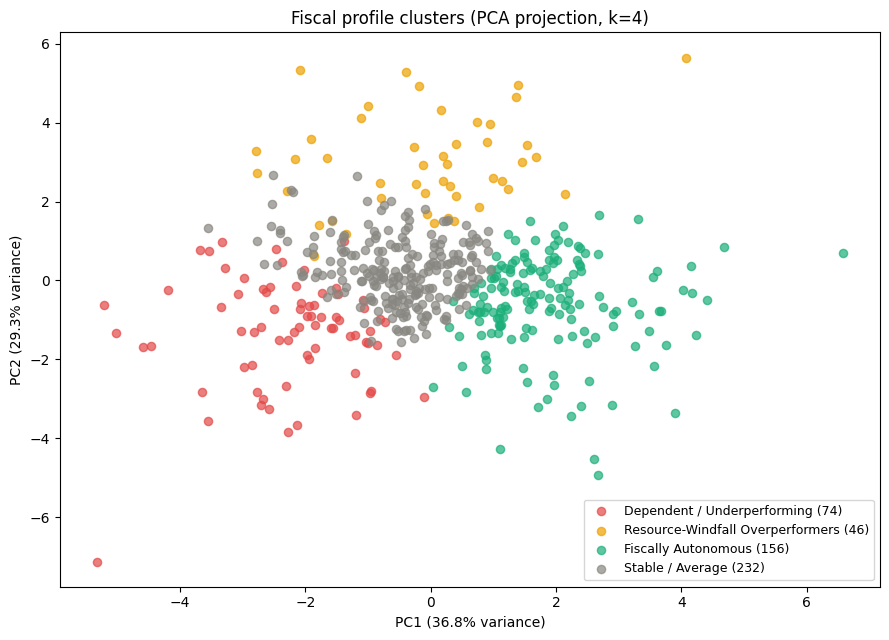

In [17]:
fig, ax = plt.subplots(figsize=(9, 6.5))
palette = {'Dependent / Underperforming': '#e34948',
           'Resource-Windfall Overperformers': '#eda100',
           'Fiscally Autonomous': '#1baf7a',
           'Stable / Average': '#898781'}

for label, color in palette.items():
    subset = df[df['cluster_label'] == label]
    ax.scatter(subset['pc1'], subset['pc2'], label=f'{label} ({len(subset)})',
               color=color, alpha=0.7, s=35)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Fiscal profile clusters (PCA projection, k=4)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('fig4_cluster_pca.png')
plt.show()

In [14]:
df.to_csv("fiscal_clustered_with_pca.csv", index=False)
print("Checkpoint saved: fiscal_clustered_with_pca.csv")
print("Shape so far:", df.shape)


Checkpoint saved: fiscal_clustered_with_pca.csv
Shape so far: (508, 22)


---
### 📤 Data Export & Handoff
* **Output File:**
`fiscal_clustered_with_pca.csv`,
`fig3_elbow_silhouette.png`, `fig4_cluster_pca.png`
* **Next Destination:** `notebooks/04_Finalizing.ipynb`
